# 03 — Эксперименты и выбор финальной модели

In [1]:
import os
os.chdir("/kaggle/working")
print("теперь в:", os.getcwd())

теперь в: /kaggle/working


In [3]:
import os, glob, sys, pathlib, subprocess

os.chdir("/kaggle/working")          # всегда стартуем из существующей папки
REPO = "/kaggle/working/repo"
subprocess.run(["rm","-rf",REPO])

r = subprocess.run(["git","clone","-b","project-defense",
    "https://github.com/FilthyName/Processing_and_analysis_of_medical_images.git", REPO],
    capture_output=True, text=True)
print(r.returncode, r.stderr)

os.chdir(REPO)
sys.path.append(f"{REPO}/src")
print("src на месте:", os.path.exists(f"{REPO}/src/common.py"))

# метаданные
cands = glob.glob("/kaggle/input/**/HAM10000_metadata.csv", recursive=True)
METADATA = cands[0]; print("metadata:", METADATA)

# картинки -> симлинки в один dir
IMAGES_DIR = "/kaggle/working/images"
pathlib.Path(IMAGES_DIR).mkdir(exist_ok=True)
for p in glob.glob("/kaggle/input/**/*.jpg", recursive=True):
    link = os.path.join(IMAGES_DIR, os.path.basename(p))
    if not os.path.exists(link):
        os.symlink(p, link)
print("картинок прилинковано:", len(glob.glob(f"{IMAGES_DIR}/*.jpg")), "(ожидаем 10015)")

0 Cloning into '/kaggle/working/repo'...

src на месте: True
metadata: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
картинок прилинковано: 10015 (ожидаем 10015)


In [4]:
!python src/make_splits.py --metadata "{METADATA}" --images-dir "{IMAGES_DIR}" --out-dir data/splits --seed 42

Всего: 10015 изображений, 7470 уникальных lesion

=== ПРОВЕРКА СПЛИТОВ ===
lesion_id overlap train∩val: 0  [OK]
lesion_id overlap train∩test: 0  [OK]
lesion_id overlap val∩test: 0  [OK]

Изображения: train 7145 / val 1429 / test 1441 = 10015
Lesion:      train 5336 / val 1067 / test 1067 = 7470
Доли (img):  train 0.713 / val 0.143 / test 0.144

Доли классов по сплитам:
       train    val   test
label                     
akiec  0.034  0.034  0.024
bcc    0.050  0.047  0.062
bkl    0.109  0.106  0.117
df     0.011  0.019  0.006
mel    0.114  0.107  0.101
nv     0.667  0.673  0.676
vasc   0.014  0.014  0.015

Абсолютные counts (важно для df/vasc):
       train  val  test
label                  
akiec    244   49    34
bcc      358   67    89
bkl      780  151   168
df        79   27     9
mel      814  153   146
nv      4769  962   974
vasc     101   20    21
  ВНИМАНИЕ: класс df в test = 9 (< 10) — метрика по нему будет шумной

Итог: ВСЕ ПРОВЕРКИ ПРОЙДЕНЫ
Сохранено: data/splits/train.c

In [5]:
import time
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn
import common as C, evaluation as E

C.set_seed(42)
DEVICE = C.resolve_device("auto")
CLASSES = ["akiec","bcc","bkl","df","mel","nv","vasc"]
SPLITS_DIR = "data/splits"        
MODELS_DIR = Path("models"); MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path("results"); RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR = Path("plots"); PLOTS_DIR.mkdir(exist_ok=True)
EPOCHS = 10
print("device:", DEVICE)

device: cuda


## Веса классов (компенсация дисбаланса)

In [6]:
train_df, val_df, test_df = C.load_splits(SPLITS_DIR)
class_weights = C.compute_class_weights(train_df, CLASSES)
print("class weights:", [round(float(w),2) for w in class_weights])
print("sizes:", len(train_df), len(val_df), len(test_df))

class weights: [4.18, 2.85, 1.31, 12.92, 1.25, 0.21, 10.11]
sizes: 7145 1429 1441


## Описание экспериментов 

In [7]:
experiments = [
  dict(name="baseline_resnet18_light",  arch="resnet18",          aug="light",  opt="adam",  lr=1e-3, wd=0.0,  bs=32, kw=dict(dropout=0.2)),
  dict(name="resnet18_strong",          arch="resnet18",          aug="strong", opt="adam",  lr=1e-3, wd=0.0,  bs=32, kw=dict(dropout=0.3)),
  dict(name="resnet18_finetune",        arch="resnet18_finetune", aug="strong", opt="adamw", lr=3e-4, wd=1e-4, bs=32, kw=dict(dropout=0.3)),
  dict(name="mobilenet_v2",             arch="mobilenet_v2",      aug="strong", opt="adam",  lr=1e-3, wd=0.0,  bs=32, kw=dict(dropout=0.2)),
  dict(name="efficientnet_b0",          arch="efficientnet_b0",   aug="strong", opt="adamw", lr=1e-4, wd=1e-4, bs=32, kw=dict(unfreeze_last_blocks=True, dropout=0.3)),
  dict(name="vit_b16",                  arch="vit_b_16",          aug="strong", opt="adamw", lr=1e-5, wd=1e-4, bs=16, kw=dict(unfreeze_last_blocks=2, dropout=0.3)),
]
pd.DataFrame([{k:v for k,v in e.items() if k!="kw"} for e in experiments])

,name,arch,aug,opt,lr,wd,bs
0,baseline_resnet18_light,resnet18,light,adam,0.00100,0.0000,32
1,resnet18_strong,resnet18,strong,adam,0.00100,0.0000,32
2,resnet18_finetune,resnet18_finetune,strong,adamw,0.00030,0.0001,32
3,mobilenet_v2,mobilenet_v2,strong,adam,0.00100,0.0000,32
4,efficientnet_b0,efficientnet_b0,strong,adamw,0.00010,0.0001,32
5,vit_b16,vit_b_16,strong,adamw,0.00001,0.0001,16


## Запуск: обучение + отбор лучшей эпохи по VAL
test здесь не трогаем. Веса лучшей по val эпохи сохраняются в models/.

In [8]:
rows = []
for exp in experiments:
    print("="*80, "\n", exp["name"])
    tr_loader, va_loader, _, _ = C.make_loaders_explicit(
        SPLITS_DIR, IMAGES_DIR, CLASSES, image_size=224,
        augmentation=exp["aug"], batch_size=exp["bs"], num_workers=2)
    model = C.build_model(exp["arch"], num_classes=len(CLASSES), **exp["kw"])
    t0 = time.time()
    model, history, best_val_f1 = C.fit(
        model, tr_loader, va_loader, device=DEVICE, epochs=EPOCHS,
        optimizer_name=exp["opt"], lr=exp["lr"], weight_decay=exp["wd"],
        class_weights=class_weights, num_classes=len(CLASSES), selection_metric="macro_f1")
    minutes = (time.time()-t0)/60
    torch.save(model.state_dict(), MODELS_DIR/f"best_{exp['name']}.pt")
    rows.append(dict(experiment=exp["name"], arch=exp["arch"],
                     val_macro_f1=round(best_val_f1,4),
                     val_accuracy=round(max(history["val_accuracy"]),4),
                     train_minutes=round(minutes,1),
                     trainable_params=C.count_trainable_params(model)))
    print(f"-> best VAL macro-F1 = {best_val_f1:.4f}  ({minutes:.1f} мин)")

 baseline_resnet18_light
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s] 


epoch 01 | train_loss 1.6476 | val_f1 0.3610 | val_acc 0.5871 | val_auc 0.8696
epoch 02 | train_loss 1.2823 | val_f1 0.4016 | val_acc 0.6319 | val_auc 0.8877
epoch 03 | train_loss 1.1775 | val_f1 0.4404 | val_acc 0.6683 | val_auc 0.9009
epoch 04 | train_loss 1.1239 | val_f1 0.4297 | val_acc 0.6235 | val_auc 0.8981
epoch 05 | train_loss 1.1210 | val_f1 0.4510 | val_acc 0.7026 | val_auc 0.9082
epoch 06 | train_loss 1.0714 | val_f1 0.4222 | val_acc 0.5815 | val_auc 0.8953
epoch 07 | train_loss 1.0815 | val_f1 0.4527 | val_acc 0.6060 | val_auc 0.9021
epoch 08 | train_loss 1.0532 | val_f1 0.4494 | val_acc 0.6221 | val_auc 0.9050
epoch 09 | train_loss 1.0397 | val_f1 0.4732 | val_acc 0.6494 | val_auc 0.9079
epoch 10 | train_loss 1.0091 | val_f1 0.4698 | val_acc 0.6620 | val_auc 0.9106
-> best VAL macro-F1 = 0.4732  (7.9 мин)
 resnet18_strong
epoch 01 | train_loss 1.7269 | val_f1 0.3614 | val_acc 0.5815 | val_auc 0.8759
epoch 02 | train_loss 1.4278 | val_f1 0.3721 | val_acc 0.5696 | val_auc 0

100%|██████████| 13.6M/13.6M [00:00<00:00, 97.2MB/s]


epoch 01 | train_loss 1.5889 | val_f1 0.4183 | val_acc 0.6256 | val_auc 0.8868
epoch 02 | train_loss 1.2905 | val_f1 0.4532 | val_acc 0.6305 | val_auc 0.8976
epoch 03 | train_loss 1.2061 | val_f1 0.4504 | val_acc 0.6186 | val_auc 0.9056
epoch 04 | train_loss 1.1688 | val_f1 0.4887 | val_acc 0.6508 | val_auc 0.9122
epoch 05 | train_loss 1.1242 | val_f1 0.4769 | val_acc 0.6137 | val_auc 0.9086
epoch 06 | train_loss 1.0888 | val_f1 0.4853 | val_acc 0.6781 | val_auc 0.9093
epoch 07 | train_loss 1.1052 | val_f1 0.4811 | val_acc 0.6361 | val_auc 0.9107
epoch 08 | train_loss 1.0594 | val_f1 0.5104 | val_acc 0.6599 | val_auc 0.9137
epoch 09 | train_loss 1.0717 | val_f1 0.4736 | val_acc 0.6480 | val_auc 0.9110
epoch 10 | train_loss 1.0520 | val_f1 0.5257 | val_acc 0.7012 | val_auc 0.9163
-> best VAL macro-F1 = 0.5257  (9.6 мин)
 efficientnet_b0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightma

100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s] 


epoch 01 | train_loss 1.6603 | val_f1 0.4314 | val_acc 0.5878 | val_auc 0.8864
epoch 02 | train_loss 1.2406 | val_f1 0.4823 | val_acc 0.6375 | val_auc 0.9084
epoch 03 | train_loss 1.0764 | val_f1 0.5076 | val_acc 0.6655 | val_auc 0.9178
epoch 04 | train_loss 0.9774 | val_f1 0.5382 | val_acc 0.6753 | val_auc 0.9248
epoch 05 | train_loss 0.8923 | val_f1 0.5335 | val_acc 0.6697 | val_auc 0.9280
epoch 06 | train_loss 0.8415 | val_f1 0.5493 | val_acc 0.6914 | val_auc 0.9288
epoch 07 | train_loss 0.8141 | val_f1 0.5494 | val_acc 0.6837 | val_auc 0.9295
epoch 08 | train_loss 0.7870 | val_f1 0.5641 | val_acc 0.6970 | val_auc 0.9312
epoch 09 | train_loss 0.7692 | val_f1 0.5701 | val_acc 0.7159 | val_auc 0.9330
epoch 10 | train_loss 0.7262 | val_f1 0.5690 | val_acc 0.7026 | val_auc 0.9333
-> best VAL macro-F1 = 0.5701  (9.7 мин)
 vit_b16
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 211MB/s]  


epoch 01 | train_loss 1.6088 | val_f1 0.4084 | val_acc 0.6088 | val_auc 0.9023
epoch 02 | train_loss 1.1131 | val_f1 0.5208 | val_acc 0.6760 | val_auc 0.9285
epoch 03 | train_loss 0.9513 | val_f1 0.5683 | val_acc 0.6844 | val_auc 0.9389
epoch 04 | train_loss 0.8358 | val_f1 0.5675 | val_acc 0.7026 | val_auc 0.9417
epoch 05 | train_loss 0.7525 | val_f1 0.6499 | val_acc 0.7677 | val_auc 0.9489
epoch 06 | train_loss 0.7099 | val_f1 0.5831 | val_acc 0.6872 | val_auc 0.9405
epoch 07 | train_loss 0.6485 | val_f1 0.6022 | val_acc 0.7103 | val_auc 0.9443
epoch 08 | train_loss 0.6186 | val_f1 0.6495 | val_acc 0.7369 | val_auc 0.9492
epoch 09 | train_loss 0.5640 | val_f1 0.6643 | val_acc 0.7488 | val_auc 0.9490
epoch 10 | train_loss 0.5478 | val_f1 0.6490 | val_acc 0.7684 | val_auc 0.9510
-> best VAL macro-F1 = 0.6643  (42.0 мин)


## Сравнение и выбор победителя — ПО VAL

In [9]:
results = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
results.to_csv(RESULTS_DIR/"experiments_comparison.csv", index=False)
winner = results.iloc[0]["experiment"]
print("Победитель (по val macro-F1):", winner)
results

Победитель (по val macro-F1): vit_b16


,experiment,arch,val_macro_f1,val_accuracy,train_minutes,trainable_params
0,vit_b16,vit_b_16,0.6643,0.7684,42.0,14181127
1,resnet18_finetune,resnet18_finetune,0.6348,0.7509,9.5,8397319
2,efficientnet_b0,efficientnet_b0,0.5701,0.7159,9.7,1138359
3,mobilenet_v2,mobilenet_v2,0.5257,0.7012,9.6,8967
4,resnet18_strong,resnet18,0.4996,0.7005,9.7,3591
5,baseline_resnet18_light,resnet18,0.4732,0.7026,7.9,3591


## Оценка победителя (per-class, mel, CI, матрицы)

In [10]:
win_exp = next(e for e in experiments if e["name"]==winner)
_, _, te_loader, _ = C.make_loaders_explicit(
    SPLITS_DIR, IMAGES_DIR, CLASSES, image_size=224,
    augmentation=win_exp["aug"], batch_size=win_exp["bs"], num_workers=2)
win_model = C.build_model(win_exp["arch"], num_classes=len(CLASSES), **win_exp["kw"]).to(DEVICE)
win_model.load_state_dict(torch.load(MODELS_DIR/f"best_{winner}.pt", map_location=DEVICE))

crit = nn.CrossEntropyLoss()
test_out = C.evaluate(win_model, te_loader, crit, DEVICE, len(CLASSES))
res = E.evaluate_predictions(
    test_out["targets"], test_out["preds"], test_out["probs"], CLASSES,
    out_dir=PLOTS_DIR, clinical_positive="mel", n_boot=1000)

=== PER-CLASS ===
              precision  recall      f1  support
akiec            0.3088  0.6176  0.4118       34
bcc              0.6146  0.6629  0.6378       89
bkl              0.4089  0.7619  0.5322      168
df               0.2727  0.3333  0.3000        9
mel              0.4274  0.3630  0.3926      146
nv               0.9605  0.7998  0.8728      974
vasc             0.9444  0.8095  0.8718       21
macro avg        0.5625  0.6211  0.5741     1441
weighted avg     0.8009  0.7356  0.7555     1441

macro-F1 = 0.5741  (95% CI 0.5213–0.6182)
accuracy = 0.7356  (95% CI 0.7148–0.7592)

=== КЛИНИКА (mel) ===
  mel_sensitivity: 0.363
  mel_specificity: 0.9452
  mel_precision: 0.4274
  mel_miss_rate: 0.637
  mel_support: 146
  mel_roc_auc: 0.8395

=== ТОП ПУТАЕМЫХ ПАР (true -> pred) ===
true  pred  count  share_of_true
  nv   bkl    109         0.1119
  nv   mel     60         0.0616
 mel   bkl     57         0.3904
 mel    nv     21         0.1438
  nv   bcc     19         0.0195
 bkl a

## Выводы по этапу экспериментов

### Постановка
Решалась задача многоклассовой классификации дерматоскопических изображений
HAM10000 (ISIC-2018) на 7 классов: akiec, bcc, bkl, df, mel, nv, vasc.
Данные сильно несбалансированы (nv ≈ 67%, df/vasc ≈ 1%), поэтому основной
метрикой выбрана macro-F1 (равный вес всех классов), а accuracy используется
только как вспомогательная. Отдельно отслеживалась клиническая метрика —
sensitivity (recall) по классу mel, поскольку пропуск меланомы является
наиболее дорогой ошибкой.

### Устранение утечки данных
В исходных сплитах деление выполнялось по изображениям без учёта lesion_id.
Так как в HAM10000 одному образованию (lesion_id) соответствует несколько
снимков, это приводило к попаданию снимков одного образования одновременно
в train и test. Диагностика показала, что **13.5% образований (1008 из 7470)
были размазаны по нескольким сплитам** — это завышало метрики.

Сплиты пересозданы группо-стратифицированным методом по lesion_id
(StratifiedGroupKFold, seed=42): каждое образование целиком находится в одном
сплите, пересечения групп между train/val/test отсутствуют, доли классов
сохранены. Итоговое деление — 71/14/14.

### Сравнение моделей (выбор по val macro-F1)
Сравнивались 6 архитектур (transfer learning) на чистых сплитах. Лучшая эпоха
каждой модели и финальный выбор модели выполнялись по validation, test
использовался один раз для финальной оценки.

| Модель | val macro-F1 | trainable params | время |
|---|---|---|---|
| **ViT-B/16** | **0.6643** | 14.2M | 42 мин |
| ResNet-18 fine-tune | 0.6348 | 8.4M | 9.5 мин |
| EfficientNet-B0 | 0.5701 | 1.1M | 9.7 мин |
| MobileNetV2 | 0.5257 | 9K | 9.6 мин |
| ResNet-18 (strong aug) | 0.4996 | 3.6K | 9.7 мин |
| ResNet-18 (baseline) | 0.4732 | 3.6K | 7.9 мин |

Наблюдается ожидаемая иерархия: замороженный CNN-бейзлайн < аугментации 
fine-tuning / современные сети < Vision Transformer. Прирост качества
коррелирует с числом обучаемых параметров и вычислительной стоимостью.
**Финальная модель — ViT-B/16.**

### Честная оценка на test
| Метрика | Значение |
|---|---|
| macro-F1 | **0.574** (95% CI 0.521–0.618) |
| accuracy | 0.736 (95% CI 0.715–0.759) |

Относительно прежних 0.64 на сплитах с утечкой macro-F1 снизился на ~0.07.
Это не деградация модели, а устранение завышения: 0.574 отражает реальную
обобщающую способность на ранее не виденных образованиях. Широкий
доверительный интервал обусловлен малочисленностью редких классов (df = 9
примеров в test).

### Качество по классам
| Класс | F1 | recall | support |
|---|---|---|---|
| nv | 0.87 | 0.80 | 974 |
| vasc | 0.87 | 0.81 | 21 |
| bcc | 0.64 | 0.66 | 89 |
| bkl | 0.53 | 0.76 | 168 |
| akiec | 0.41 | 0.62 | 34 |
| mel | 0.39 | 0.36 | 146 |
| df | 0.30 | 0.33 | 9 |

Хорошо распознаются массовый nv и визуально характерный vasc. Слабее всего —
mel, akiec, bkl, df: классы либо визуально близки между собой, либо
малочисленны.

### Клиническая оценка (меланома)
| Метрика mel | Значение |
|---|---|
| sensitivity (recall) | 0.363 |
| miss rate | 0.637 |
| specificity | 0.945 |
| precision | 0.427 |
| ROC-AUC (one-vs-rest) | 0.840 |

Модель **пропускает ~64% меланом** (53 из 146 распознаны верно). При этом
ROC-AUC по mel = 0.84 показывает, что разделяющая способность присутствует —
проблема в смещённом из-за дисбаланса пороге принятия решения, а не в
неспособности модели различать меланому в принципе. **В текущем виде модель
непригодна как клинический скрининговый инструмент.**

### Анализ ошибок
Основные каналы путаницы (true → pred):
- **mel → bkl: 57 (39% всех меланом)** — главный источник пропуска меланомы;
- mel → nv: 21 (14%) — меланома принимается за доброкачественный невус;
- nv → bkl: 109, nv → mel: 60 — ложные срабатывания на родинках.

Пары mel/bkl/nv визуально близки и трудноразделимы без дерматоскопических
признаков, поэтому часть ошибок объективно трудноустранима на уровне
изображения.

### Ограничения и направления улучшения
1. **Низкая чувствительность к меланоме** — основной риск. Возможные меры:
   калибровка порога / снижение порога для mel, focal loss, перевзвешивание.
2. **Дисбаланс и редкие классы (df, vasc)** — oversampling, аугментация,
   доразметка.
3. **Артефакты съёмки** (волосы, линейка, фон) — использование
   сегментационных масок ISIC для кропа очага.
4. **Шумная оценка редких классов** — расширение test или k-fold.


=== ПОДБОР ПОРОГА (на VAL) ===
  thr    sens    prec  macroF1
  0.1   0.804   0.301    0.660
  0.2   0.654   0.383    0.665
  0.3   0.523   0.462    0.665
  0.4   0.438   0.519    0.662
  0.5   0.431   0.545    0.664
  0.6   0.431   0.545    0.664
  0.7   0.431   0.545    0.664
  0.8   0.431   0.545    0.664
  0.9   0.431   0.545    0.664

Выбранный порог (sens>=0.8 на val): 0.100

[argmax (было)]  mel_sens=0.363  miss_rate=0.637  mel_prec=0.427  macroF1=0.574  acc=0.736

[порог mel=0.10]  mel_sens=0.781  miss_rate=0.219  mel_prec=0.246  macroF1=0.552  acc=0.639


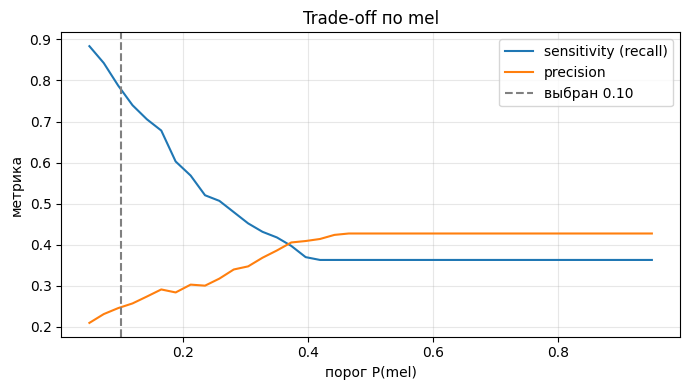

In [12]:
import numpy as np, torch.nn as nn
from sklearn.metrics import f1_score, recall_score, precision_score
import matplotlib.pyplot as plt

MEL = CLASSES.index("mel")

_, va_loader, _, _ = C.make_loaders_explicit(
    SPLITS_DIR, IMAGES_DIR, CLASSES, image_size=224,
    augmentation=win_exp["aug"], batch_size=win_exp["bs"], num_workers=2)
val_out = C.evaluate(win_model, va_loader, nn.CrossEntropyLoss(), DEVICE, len(CLASSES))

def pred_mel_thr(probs, t):
    p = probs.argmax(1).copy()
    p[probs[:, MEL] >= t] = MEL
    return p

def mel_sp(targets, preds):
    yt, yp = targets == MEL, preds == MEL
    return recall_score(yt, yp, zero_division=0), precision_score(yt, yp, zero_division=0)

# смотрим trade-off
print("=== ПОДБОР ПОРОГА (на VAL) ===")
print(f"{'thr':>5} {'sens':>7} {'prec':>7} {'macroF1':>8}")
for t in np.round(np.linspace(0.1, 0.9, 9), 2):
    vp = pred_mel_thr(val_out["probs"], t)
    s, pr = mel_sp(val_out["targets"], vp)
    mf = f1_score(val_out["targets"], vp, average="macro", zero_division=0)
    print(f"{t:>5} {s:>7.3f} {pr:>7.3f} {mf:>8.3f}")

# выбираем максимальный порог, дающий sensitivity>=0.80 на VAL
TARGET = 0.80
grid = np.round(np.linspace(0.02, 0.95, 94), 3)
ok = [t for t in grid if mel_sp(val_out["targets"], pred_mel_thr(val_out["probs"], t))[0] >= TARGET]
THR = float(max(ok)) if ok else 0.02
print(f"\nВыбранный порог (sens>={TARGET} на val): {THR:.3f}")

# применяем к тест: до / после
base = test_out["preds"]
tuned = pred_mel_thr(test_out["probs"], THR)
for name, preds in [("argmax (было)", base), (f"порог mel={THR:.2f}", tuned)]:
    s, pr = mel_sp(test_out["targets"], preds)
    mf = f1_score(test_out["targets"], preds, average="macro", zero_division=0)
    acc = (test_out["targets"] == preds).mean()
    print(f"\n[{name}]  mel_sens={s:.3f}  miss_rate={1-s:.3f}  "
          f"mel_prec={pr:.3f}  macroF1={mf:.3f}  acc={acc:.3f}")

ts = np.round(np.linspace(0.05, 0.95, 40), 3)
sens = [mel_sp(test_out["targets"], pred_mel_thr(test_out["probs"], t))[0] for t in ts]
prec = [mel_sp(test_out["targets"], pred_mel_thr(test_out["probs"], t))[1] for t in ts]
plt.figure(figsize=(7,4))
plt.plot(ts, sens, label="sensitivity (recall)")
plt.plot(ts, prec, label="precision")
plt.axvline(THR, color="gray", ls="--", label=f"выбран {THR:.2f}")
plt.xlabel("порог P(mel)"); plt.ylabel("метрика"); plt.title("Trade-off по mel")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(PLOTS_DIR/"mel_threshold_tradeoff.png", dpi=150); plt.show()

### Итог

Финальной моделью выбрала ViT-B/16 — она показала лучший val macro-F1 (0.66)
из шести опробованных архитектур. На тесте честный macro-F1 получился 0.574
(CI 0.52–0.62), accuracy 0.736.

Раньше у меня выходило около 0.64, но потом я заметила, что сплиты сделаны
неправильно — снимки одного и того же образования (lesion_id) попадали и в
train, и в test. Из-за этого модель частично подсматривала ответы, и метрики
были завышены. Я пересплитила данные по lesion_id (13.5% образований были
размазаны по сплитам), и после этого 0.574 — это уже честная цифра.

Дальше я посмотрела на меланому отдельно и увидела проблему: sensitivity по mel
всего 0.363, то есть модель пропускала почти две трети меланом. Для задачи про
рак кожи это плохо. При этом ROC-AUC по mel был 0.84 — значит модель в принципе
умеет отличать меланому, просто из-за дисбаланса классов почти никогда не
ставила ей метку (mel — редкий класс, и argmax его забивал).

Чтобы это исправить, я не стала переобучать модель, а подобрала отдельный порог
для меланомы: если вероятность mel выше порога — ставим mel, иначе обычный
argmax. Порог подбирала на валидации. С порогом 0.10 sensitivity по меланоме
выросла с 0.363 до 0.781 — то есть теперь ловим почти 80% меланом вместо трети.
Платим за это снижением precision (0.43 → 0.25, больше ложных тревог) и чуть-чуть
macro-F1 (0.574 → 0.552). Для скрининга это нормальный размен: лишний раз
показать врача не страшно, а вот пропустить меланому — опасно.


